# Shape Assembly: Armadillo → Bunny (JAX/Equinox v2)

Non-growing tissue emulation demo using `waxmorph.jax.train` to replace the
manual training loop. Same pipeline as `shape_assembly_jax.ipynb` but with the
~100-line training cell replaced by a single `train()` call.

In [1]:
import pyglet
pyglet.options["headless"] = True

import numpy as np
import warp as wp
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import pyvista as pv
from waxmorph.render import PyVistaInterface

pv.set_jupyter_backend("html")

wp.init()
device = "cuda"

np.random.seed(42)
key = jax.random.PRNGKey(42)

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 12.4
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA H100 NVL" (93 GiB, sm_90, mempool enabled)
   Kernel cache:
     /insomnia001/home/ob2391/.cache/warp/1.12.0


## 1. Load meshes and sample point clouds

In [2]:
from waxmorph.data import sample_mesh_pair

N_POINTS = 2000
RADIUS = 0.2
NUM_GENES = 50

data = sample_mesh_pair(
    source_path="meshes/armadillo.ply",
    target_path="meshes/bunny.ply",
    n_points=N_POINTS,
    target_extent=10.0,
    radius=RADIUS,
)

print(f"Source: {data['source_pos'].shape}, Target: {data['target_pos'].shape}")

Source: (2000, 3), Target: (2000, 3)


## 2. Initialize state arrays

In [3]:
N = len(data["source_pos"])

# Positions: start from armadillo
pos_np = data["source_pos"].copy()

# Radii: uniform
rad_np = np.full(N, RADIUS, dtype=np.float32)

# Polarities: random unit vectors
rng = np.random.default_rng(42)
pol_np = rng.standard_normal((N, 3)).astype(np.float32)
pol_np /= np.linalg.norm(pol_np, axis=-1, keepdims=True) + 1e-9

# Genes: random initialization
genes_np = rng.random((N, NUM_GENES)).astype(np.float32)

print(f"Initialized {N} source particles, {len(data['target_pos'])} target points, {NUM_GENES} genes")

Initialized 2000 source particles, 2000 target points, 50 genes


## 2b. Render initial states (PyVista)

In [ ]:
morph_source = np.full(N, 0.5, dtype=np.float32)

plotter = PyVistaInterface.draw_3d_view(
    data["source_pos"], rad_np, morph_source, pol_np,
    particle_count=N, blim=-6, tlim=6, alpha=0.9,
    show_polarities=False,
)
plotter.add_title("Source (Armadillo)")
plotter.show()

In [ ]:
N_target = len(data["target_pos"])
morph_target = np.full(N_target, 0.5, dtype=np.float32)
rad_target = np.full(N_target, RADIUS, dtype=np.float32)
pol_target = np.zeros((N_target, 3), dtype=np.float32)
pol_target[:, 2] = 1.0

plotter = PyVistaInterface.draw_3d_view(
    data["target_pos"], rad_target, morph_target, pol_target,
    particle_count=N_target, blim=-6, tlim=6, alpha=0.9,
    show_polarities=False,
)
plotter.add_title("Target (Bunny)")
plotter.show()

## 3. Build GNS model

In [4]:
from waxmorph.jax.graph import build_graph
from waxmorph.jax.gnn import GNS
from waxmorph.jax.losses import make_sinkhorn_loss

# Probe feature dimensions
X_probe = wp.from_numpy(pos_np.copy(), dtype=wp.vec3f, device=device)
P_probe = wp.from_numpy(pol_np.copy(), dtype=wp.vec3f, device=device)
R_probe = wp.from_numpy(rad_np.copy(), dtype=wp.float32, device=device)
G_probe = wp.from_numpy(genes_np.copy(), dtype=wp.float32, device=device)

node_feats, edge_index, edge_feats, num_edges = build_graph(
    X_probe, P_probe, R_probe, particle_count=N, G=G_probe,
)

print(f"Node features: {node_feats.shape}")
print(f"Edge index: {edge_index.shape}  ({num_edges} directed edges)")
print(f"Edge features: {edge_feats.shape}")

model = GNS(
    node_feature_dim=node_feats.shape[1],
    edge_feature_dim=edge_feats.shape[1],
    node_latent_dim=256,
    edge_latent_dim=256,
    hidden_dim=256,
    num_mp_steps=5,
    num_mlp_layers=2,
    output_dims={"dX": 3, "dP": 3, "dG": NUM_GENES},
    checkpoint_processor=True,
    key=key,
)

n_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)))
print(f"GNS parameters: {n_params:,}")

loss_fn = make_sinkhorn_loss(blur=0.05)

optimizer = optax.adamw(3e-4)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

Node features: (2000, 50)
Edge index: (2, 8426)  (8426 directed edges)
Edge features: (8426, 2)
GNS parameters: 2,662,200


## 4. Training

In [5]:
from waxmorph.jax.train import train, TrainConfig

config = TrainConfig(n_epochs=1000, t_rollout=200)
result = train(
    model, optimizer, opt_state, loss_fn,
    source_pos=data["source_pos"],
    target_pos=data["target_pos"],
    polarities=pol_np, genes=genes_np, radii=rad_np,
    config=config,
    save_path="runs/armadillo_bunny_jax_v2.eqx",
)
model = result.model
losses = result.log["losses_total"]

  0%|                                                                                          | 0/1000 [00:00<?, ?it/s]

Module waxmorph.emulator a238c57 load on device 'cuda:0' took 1847.47 ms  (compiled)


  1%|▊                                                                              | 10/1000 [01:15<1:01:28,  3.73s/it]

Epoch   10/1000  best=3.1842  shape=3.0766  l2=107.6680


  2%|█▌                                                                               | 20/1000 [01:46<50:20,  3.08s/it]

...

Epoch  980/1000  best=0.1859  shape=0.0797  l2=106.2098


 99%|███████████████████████████████████████████████████████████████████████████████▏| 990/1000 [50:44<00:30,  3.02s/it]

Epoch  990/1000  best=0.1859  shape=0.0797  l2=106.2098


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [51:14<00:00,  3.07s/it]

Epoch 1000/1000  best=0.1805  shape=0.0711  l2=109.4292


## 5. Visualize loss curve

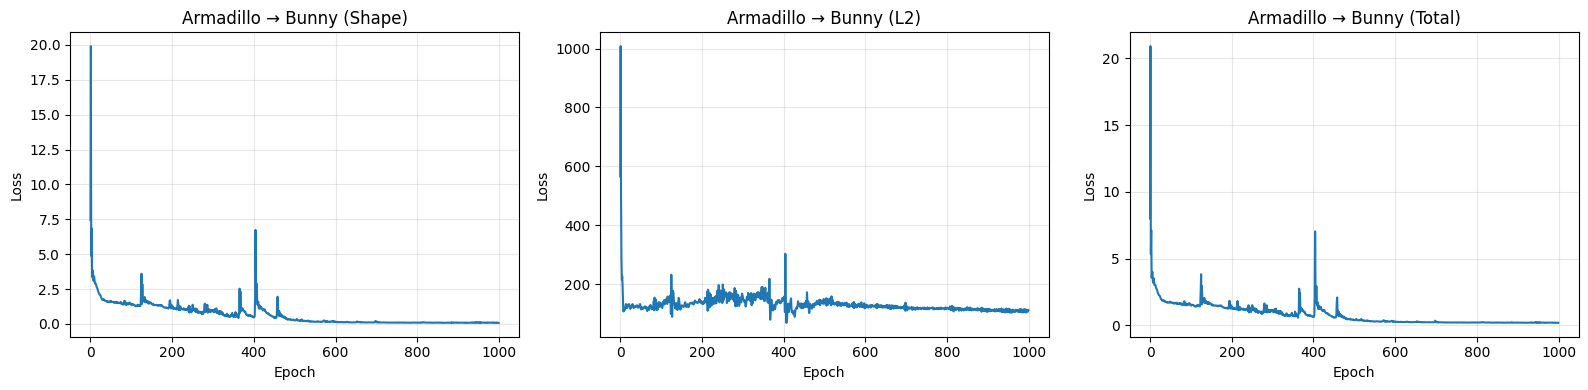

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, key, title in zip(axes, ["losses_shape", "losses_l2", "losses_total"],
                          ["Shape", "L2", "Total"]):
    ax.plot(result.log[key])
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Armadillo \u2192 Bunny ({title})")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Final rollout with trajectory capture

In [7]:
trajectory = result.log["best_traj_pos"]
X_final = trajectory[-1]
print(f"Best trajectory: {trajectory.shape[0]} frames, best loss={result.log['best_loss']:.4f}")

Best trajectory: 201 frames, best loss=0.1805


## 7. Render final state (PyVista)

In [8]:
morph_final = np.full(N, 0.5, dtype=np.float32)

plotter = PyVistaInterface.draw_3d_view(
    X_final, rad_np, morph_final, pol_np,
    particle_count=N, blim=-6, tlim=6, alpha=0.9,
    show_polarities=False,
)
plotter.add_title("Predicted (Final)")
plotter.show()

2026-03-17 17:13:46.837 (3184.743s) [    152C53796740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

## 8. Deformation movie (WarpMovieRenderer)

In [9]:
import os
from tqdm import trange
from waxmorph.render import WarpMovieRenderer

os.makedirs("Output", exist_ok=True)
VIDEO_PATH = "Output/shape_assembly_jax_v2.usd"

INTERP_STEPS = 4
colors_rgb = np.full((N, 3), [0.3, 0.6, 0.9], dtype=np.float32)

with WarpMovieRenderer(
    filename=VIDEO_PATH,
    max_particles=N,
    width=1920,
    height=1080,
    fps=30,
    device="cuda",
) as mov:
    frame_idx = 0
    n_frames = trajectory.shape[0]
    for seg in trange(n_frames - 1):
        start = trajectory[seg]
        end = trajectory[seg + 1]
        for sub in range(INTERP_STEPS):
            alpha = sub / INTERP_STEPS
            s = 3.0 * alpha**2 - 2.0 * alpha**3
            pts = start * (1.0 - s) + end * s
            mov.write_frame_from_numpy(
                t=float(frame_idx),
                centers=pts,
                radii=rad_np,
                colors=colors_rgb,
                particle_count=N,
            )
            frame_idx += 1
    for _ in trange(15):
        mov.write_frame_from_numpy(
            t=float(frame_idx),
            centers=trajectory[-1],
            radii=rad_np,
            colors=colors_rgb,
            particle_count=N,
        )
        frame_idx += 1

100%|█████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 1970.95it/s]

Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/MorphWARP/Output/shape_assembly_jax_v2.usd`
